[2026-07-28 00:47:25] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-07-28 00:47:54] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-10-31 23:59:59
[2026-07-28 00:47:54] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-28 00:47:56] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-28 00:47:57] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-10-31
[2026-07-28 00:47:57] [info     ] ========== 数据检查 ==========
[2026-07-28 00:47:57] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_l

时段,IC
2024-01-15~2024-02-08,0.0096
2024-09-24~2024-10-08,0.0282

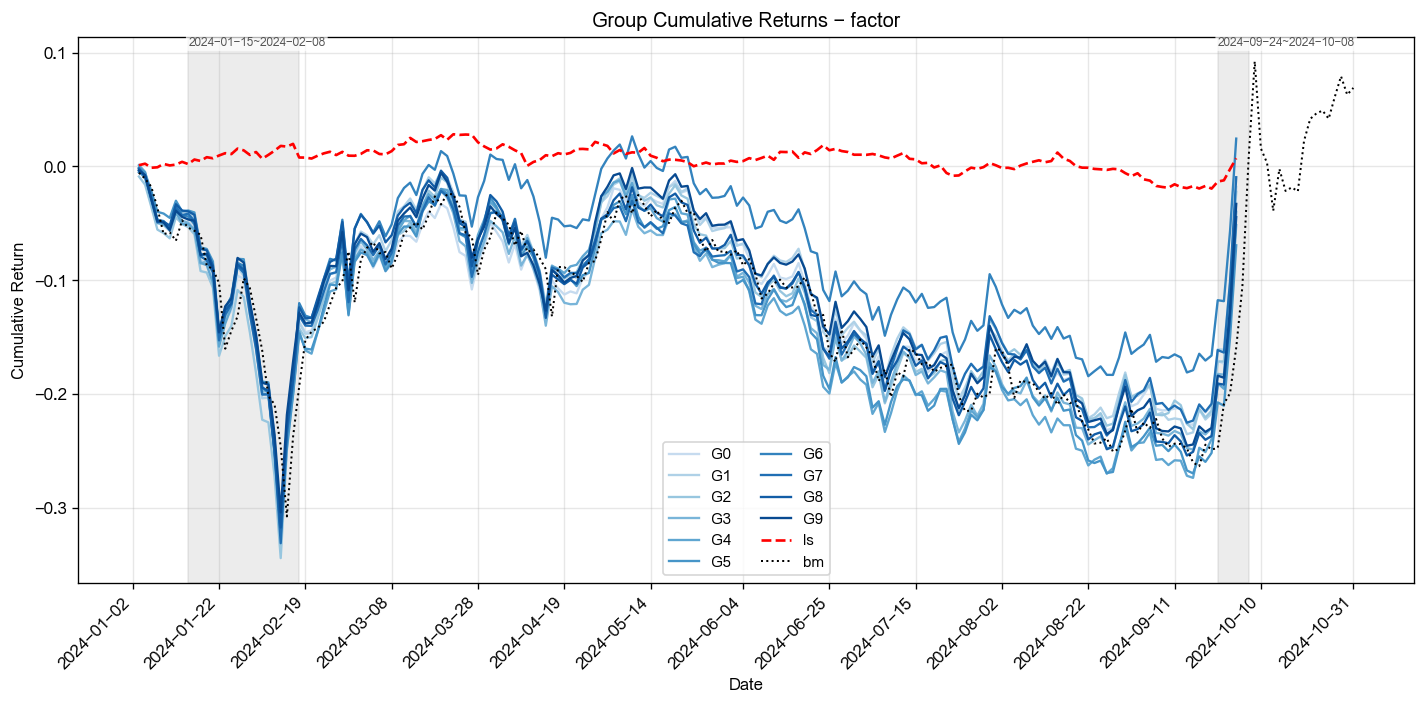
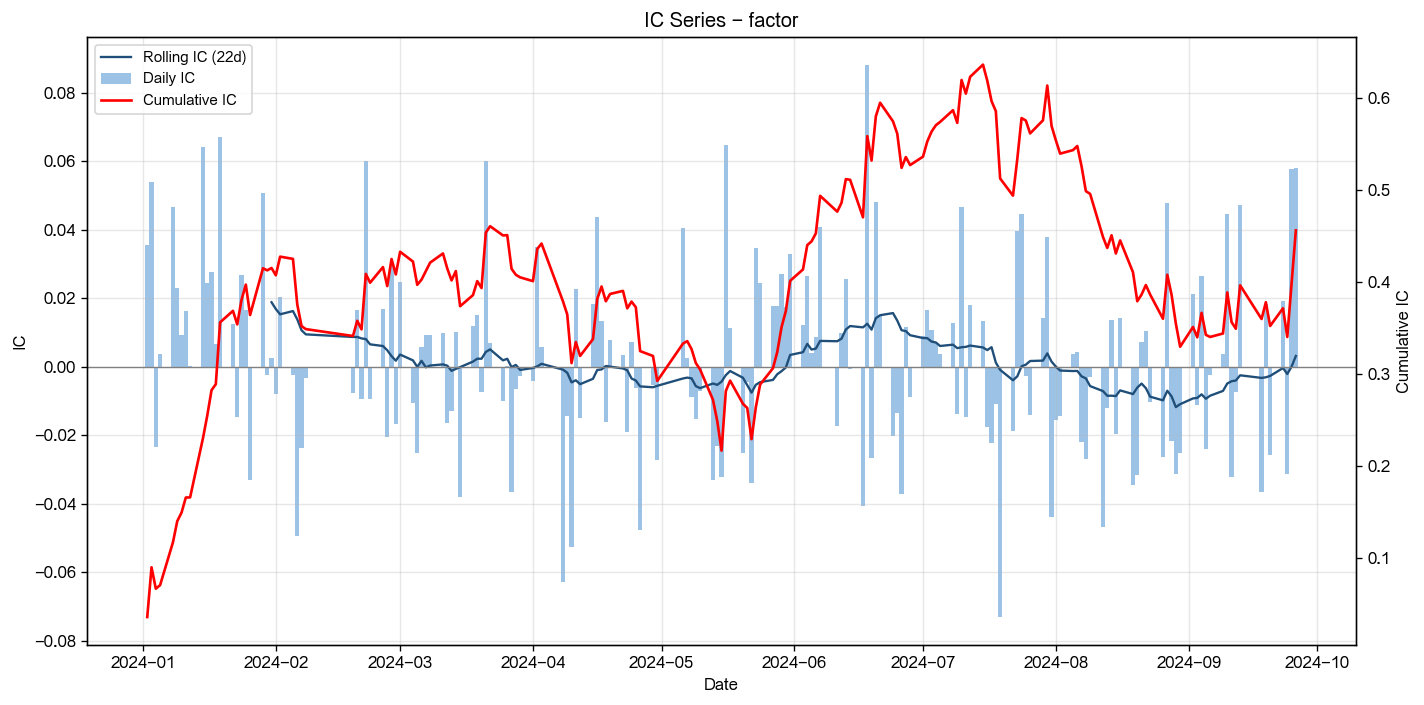
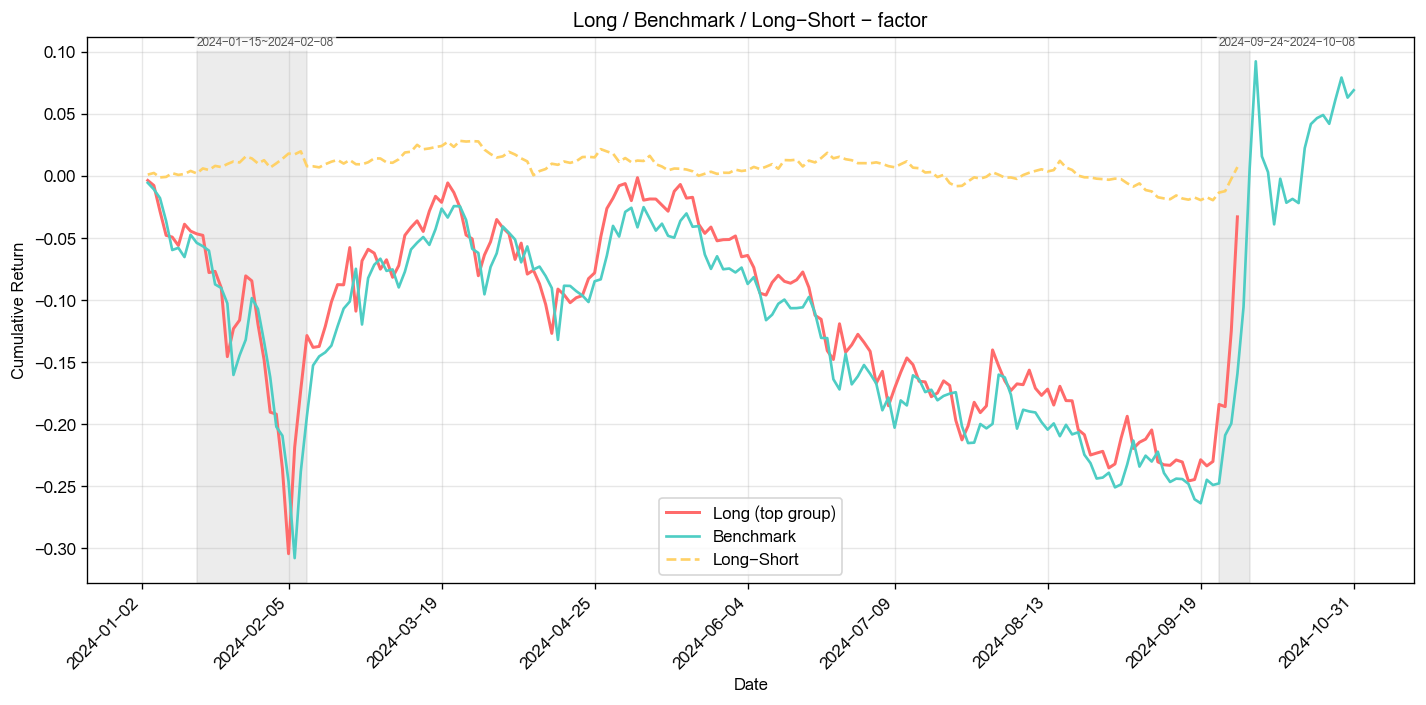
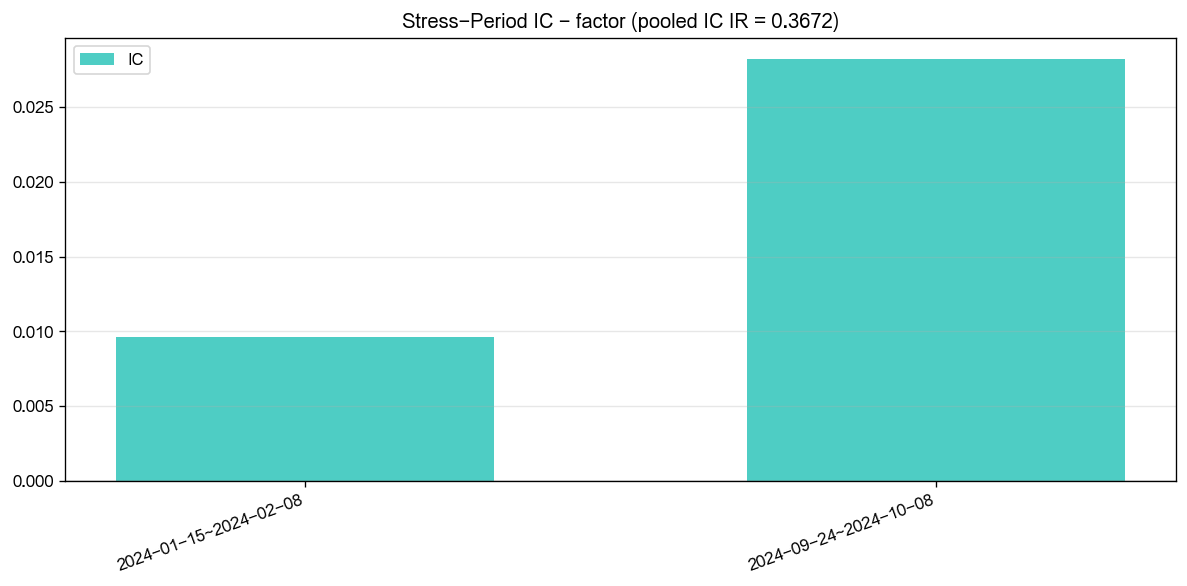
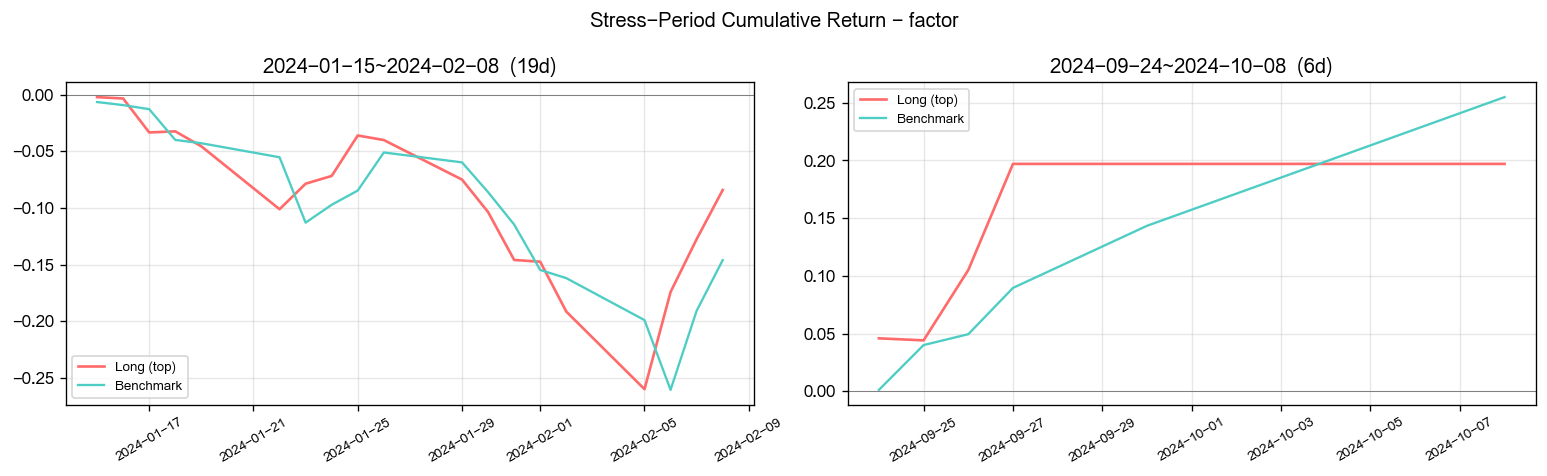

[2026-07-28 00:48:07] [info     ] ========== 因子池回归 ==========
[2026-07-28 00:48:08] [info     ] 加载 T+1 收益数据完成                  end_date=2024-10-31 instrument_count=1106 rows=228070 start_date=2024-01-02
[2026-07-28 00:48:08] [info     ] 获取收益率数据, 耗时: 0.5735 秒
[2026-07-28 00:48:08] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.0869 秒
[2026-07-28 00:48:08] [info     ] 统计 回归结果, 耗时: 0.0895 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,2.6094,0.0151,0.0058,1.0000
2,netflow_amount_rate_main,2.2070,0.0065,0.0030,1.0000
3,gross_profit_rate_ttm,1.8279,0.0079,0.0043,1.0000
4,amount,1.8211,0.0203,0.0112,0.8571
5,volatility_5,1.8174,0.0230,0.0127,1.0000
6,roa_avg_ttm,1.6623,0.0157,0.0095,0.8571
7,rsi_12,1.5762,0.0396,0.0251,1.0000
8,net_profit_rate_ttm,1.5548,0.0045,0.0029,0.8571
9,macd_dea_12_26_9,1.5441,0.0063,0.0041,0.8571
10,pb,1.5410,0.0064,0.0041,1.0000

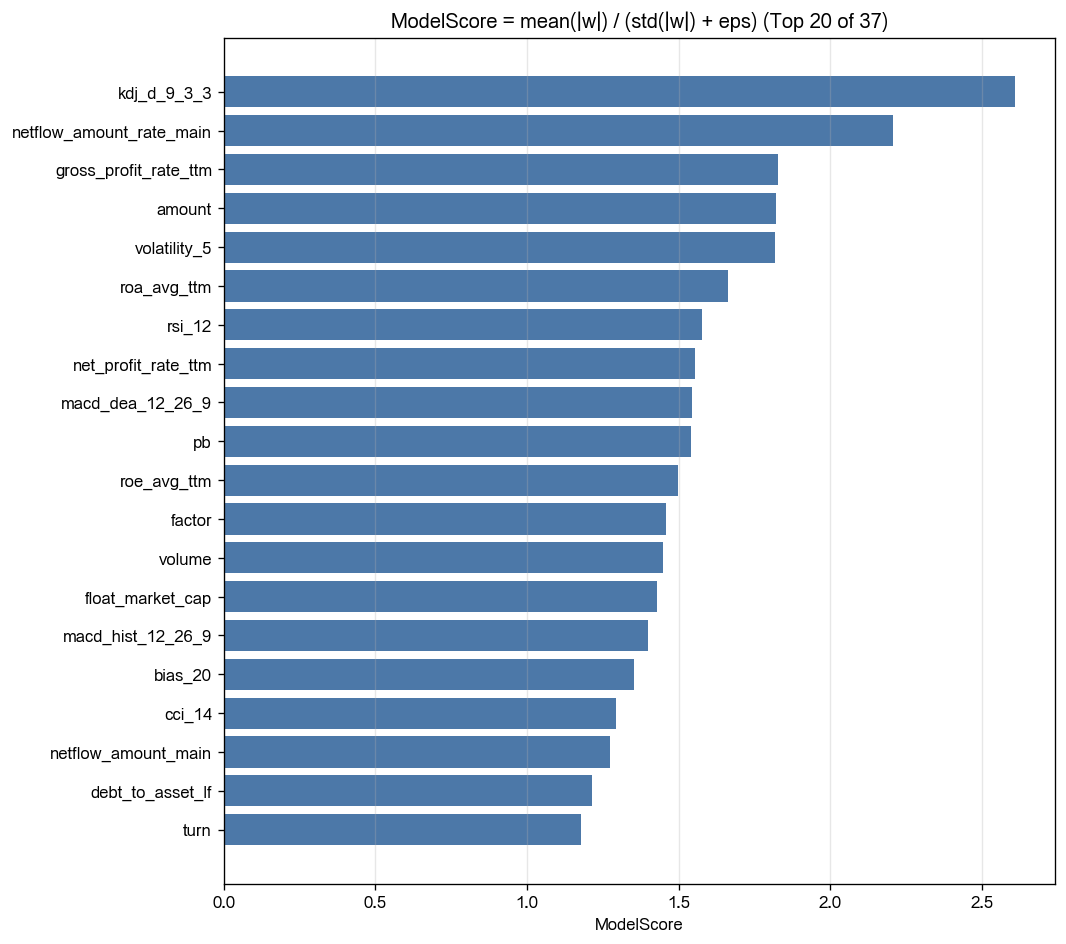
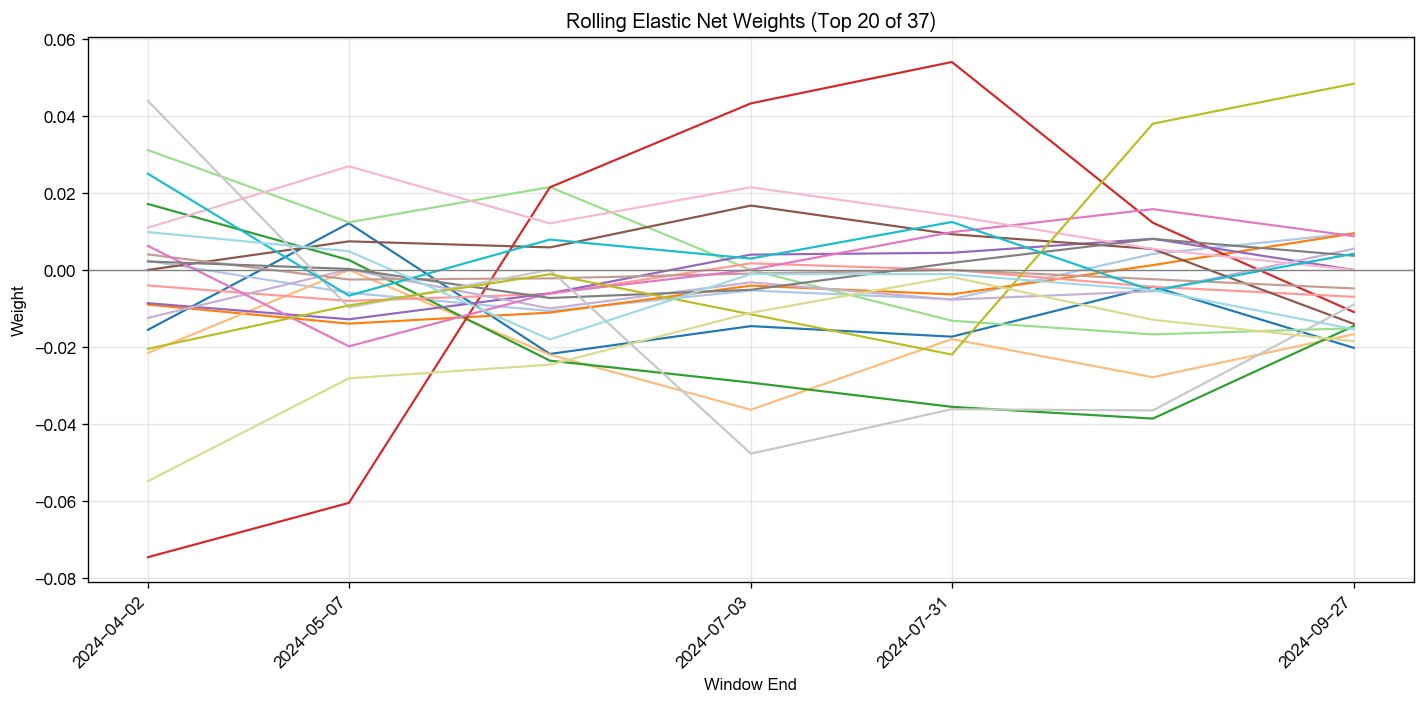
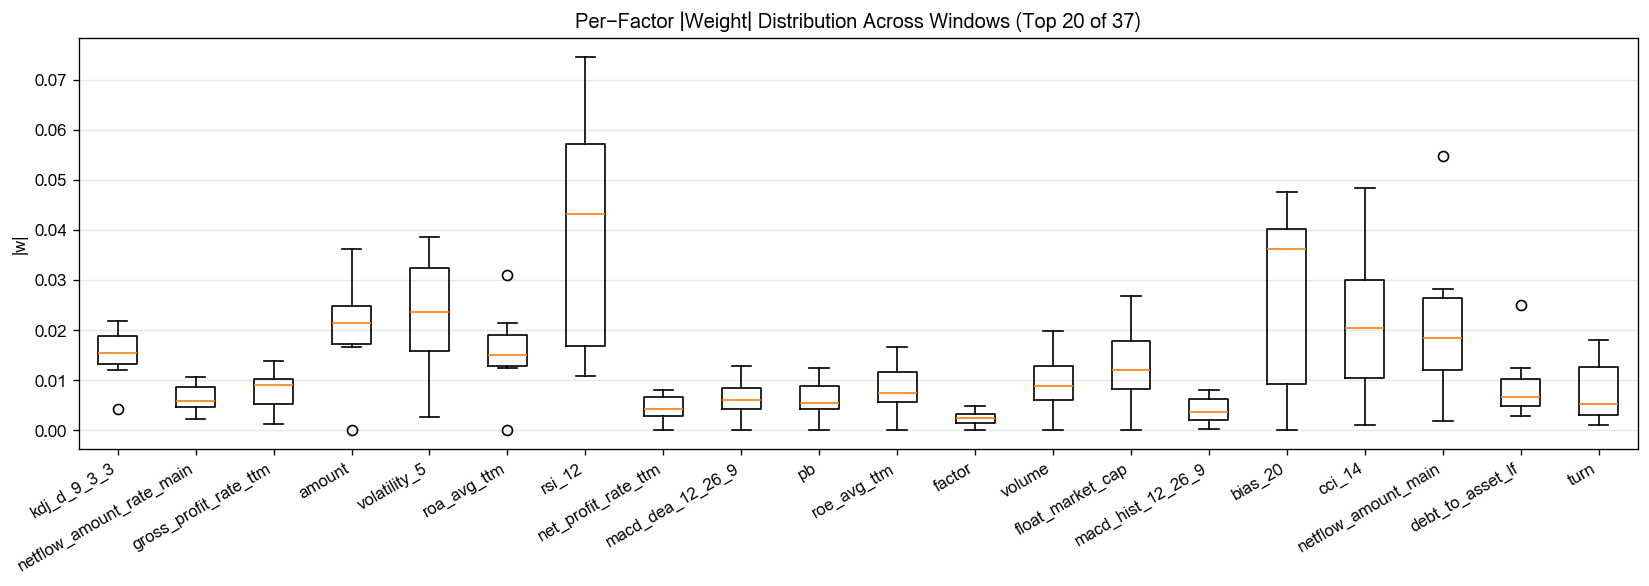
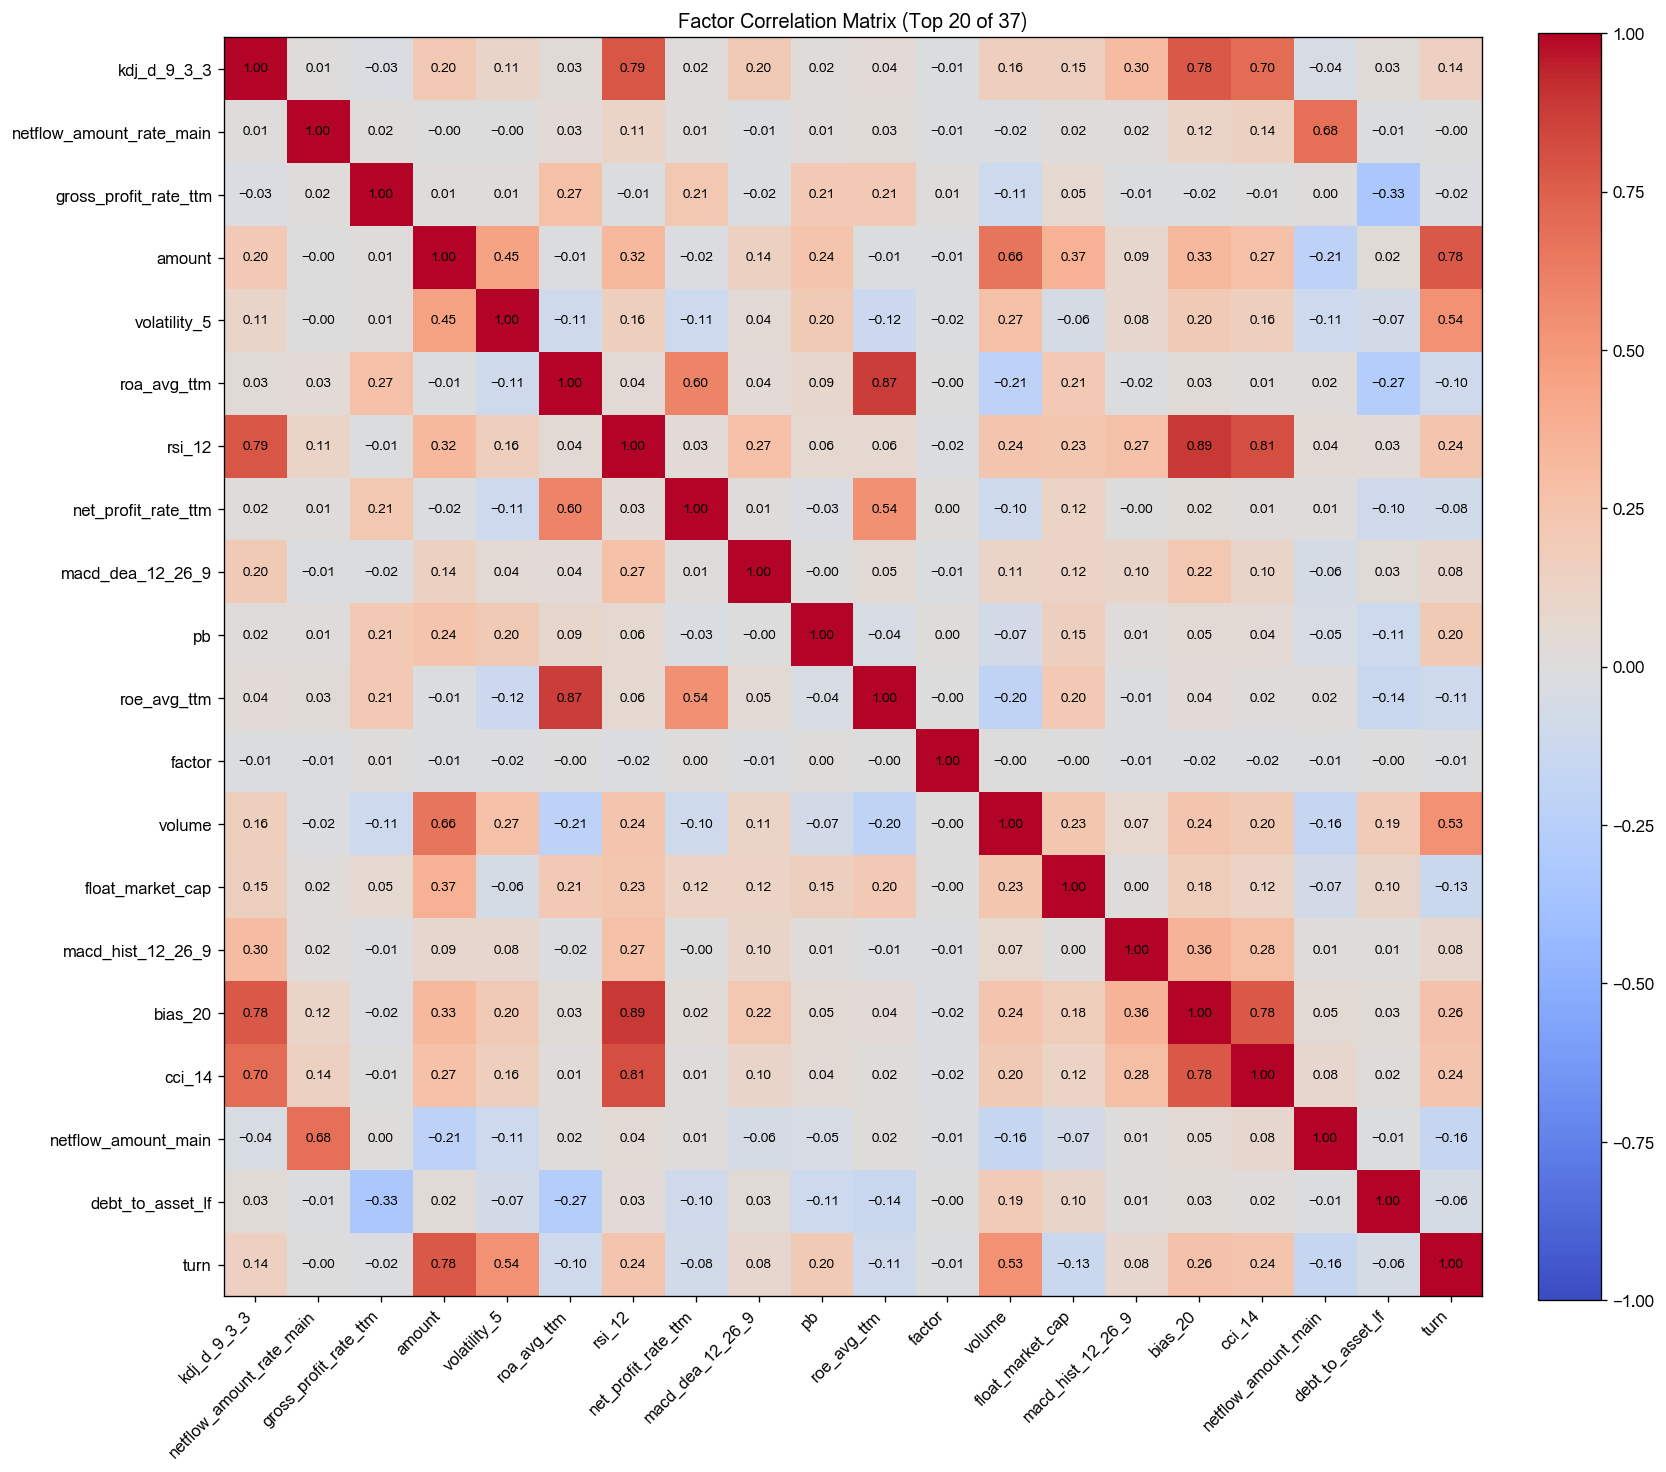

[2026-07-28 00:48:11] [warning  ] 返回的Outputs实例(size=27730194) 大于 64K, 将不会被缓存
[2026-07-28 00:48:11] [info     ] bigalpha_eval.v4 运行完成 [14.467s].


In [1]:
def main(datasources, start_date, end_date):
    """
    BigAlpha 2026 因子：
    尾盘大单排队集中度加速残差
    Late Queue Concentration Acceleration Residual (LQCAR)

    因子越大：
    尾盘买方平均挂单规模相对卖方明显增大，
    且这种变化无法由普通盘口深度、委托笔数、
    买卖价差及当日价格走势解释。
    """

    import numpy as np
    import pandas as pd
    import dai

    # 分钟表必须从 datasources 动态获取。
    bar1m = datasources["bar1m"]

    eval_start = pd.Timestamp(start_date).normalize()
    eval_end = pd.Timestamp(end_date).normalize()

    # 因子使用3日平滑，向前取14个自然日作为缓冲。
    query_start = eval_start - pd.Timedelta(days=14)

    query_start_str = query_start.strftime("%Y-%m-%d 00:00:00")
    eval_start_str = eval_start.strftime("%Y-%m-%d 00:00:00")
    eval_end_str = eval_end.strftime("%Y-%m-%d 23:59:59")

    # ============================================================
    # 一、分钟盘口聚合为日频特征
    # ============================================================

    sql = f"""
    WITH minute_base AS (
        SELECT
            date AS bar_time,
            date::DATE::DATETIME AS trading_date,
            instrument,
            close,
            high,
            low,
            amount,

            /*
            0：早盘及午后前段
            1：14:00—14:56尾盘

            排除14:57之后的收盘集合竞价。
            */
            CASE
                WHEN (
                    (hour(date) = 9 AND minute(date) >= 31)
                    OR hour(date) = 10
                    OR (hour(date) = 11 AND minute(date) <= 30)
                    OR hour(date) = 13
                ) THEN 0

                WHEN (
                    hour(date) = 14
                    AND minute(date) <= 56
                ) THEN 1

                ELSE NULL
            END AS is_tail,

            /*
            越靠近买一、卖一，权重越高。
            */
            (
                1.0 * COALESCE(bid_volume1, 0)
                + 0.8 * COALESCE(bid_volume2, 0)
                + 0.6 * COALESCE(bid_volume3, 0)
                + 0.4 * COALESCE(bid_volume4, 0)
                + 0.2 * COALESCE(bid_volume5, 0)
            ) AS weighted_bid_volume,

            (
                1.0 * COALESCE(ask_volume1, 0)
                + 0.8 * COALESCE(ask_volume2, 0)
                + 0.6 * COALESCE(ask_volume3, 0)
                + 0.4 * COALESCE(ask_volume4, 0)
                + 0.2 * COALESCE(ask_volume5, 0)
            ) AS weighted_ask_volume,

            (
                1.0 * COALESCE(bid_num_orders1, 0)
                + 0.8 * COALESCE(bid_num_orders2, 0)
                + 0.6 * COALESCE(bid_num_orders3, 0)
                + 0.4 * COALESCE(bid_num_orders4, 0)
                + 0.2 * COALESCE(bid_num_orders5, 0)
            ) AS weighted_bid_orders,

            (
                1.0 * COALESCE(ask_num_orders1, 0)
                + 0.8 * COALESCE(ask_num_orders2, 0)
                + 0.6 * COALESCE(ask_num_orders3, 0)
                + 0.4 * COALESCE(ask_num_orders4, 0)
                + 0.2 * COALESCE(ask_num_orders5, 0)
            ) AS weighted_ask_orders,

            bid_price1,
            ask_price1

        FROM {bar1m}

        WHERE
            close > 0
            AND high > 0
            AND low > 0
            AND ask_price1 > 0
            AND bid_price1 > 0
            AND ask_price1 >= bid_price1

            AND (
                (hour(date) = 9 AND minute(date) >= 31)
                OR hour(date) = 10
                OR (hour(date) = 11 AND minute(date) <= 30)
                OR hour(date) = 13
                OR (hour(date) = 14 AND minute(date) <= 56)
            )
    ),

    minute_feature AS (
        SELECT
            bar_time,
            trading_date,
            instrument,
            close,
            high,
            low,
            amount,
            is_tail,

            /*
            平均挂单规模不对称：

            买方平均挂单规模
            = 买方加权挂单量 / 买方加权委托笔数

            卖方同理。
            */
            LN(
                (
                    1.0
                    + weighted_bid_volume
                    / NULLIF(weighted_bid_orders, 0)
                )
                /
                (
                    1.0
                    + weighted_ask_volume
                    / NULLIF(weighted_ask_orders, 0)
                )
            ) AS queue_size_asymmetry,

            /*
            普通盘口挂单量失衡，后续作为控制变量。
            */
            (
                weighted_bid_volume
                - weighted_ask_volume
            )
            /
            NULLIF(
                weighted_bid_volume
                + weighted_ask_volume,
                0
            ) AS depth_imbalance,

            /*
            委托笔数失衡，后续作为控制变量。
            */
            (
                weighted_bid_orders
                - weighted_ask_orders
            )
            /
            NULLIF(
                weighted_bid_orders
                + weighted_ask_orders,
                0
            ) AS order_count_imbalance,

            /*
            相对买卖价差。
            */
            (
                ask_price1 - bid_price1
            )
            /
            NULLIF(
                0.5 * (ask_price1 + bid_price1),
                0
            ) AS relative_spread

        FROM minute_base

        WHERE
            is_tail IS NOT NULL
            AND weighted_bid_volume > 0
            AND weighted_ask_volume > 0
            AND weighted_bid_orders > 0
            AND weighted_ask_orders > 0
    ),

    daily_feature AS (
        SELECT
            trading_date AS date,
            instrument,

            AVG(
                CASE
                    WHEN is_tail = 0
                    THEN queue_size_asymmetry
                END
            ) AS early_queue_size_asymmetry,

            AVG(
                CASE
                    WHEN is_tail = 1
                    THEN queue_size_asymmetry
                END
            ) AS tail_queue_size_asymmetry,

            AVG(
                CASE
                    WHEN is_tail = 0
                    THEN depth_imbalance
                END
            ) AS early_depth_imbalance,

            AVG(
                CASE
                    WHEN is_tail = 1
                    THEN depth_imbalance
                END
            ) AS tail_depth_imbalance,

            AVG(
                CASE
                    WHEN is_tail = 0
                    THEN order_count_imbalance
                END
            ) AS early_order_count_imbalance,

            AVG(
                CASE
                    WHEN is_tail = 1
                    THEN order_count_imbalance
                END
            ) AS tail_order_count_imbalance,

            AVG(
                CASE
                    WHEN is_tail = 1
                    THEN relative_spread
                END
            ) AS tail_relative_spread,

            /*
            所有依赖先后顺序的聚合函数
            都显式指定ORDER BY。
            */
            FIRST(close ORDER BY bar_time) AS first_close,
            LAST(close ORDER BY bar_time) AS last_close,

            MAX(high) AS day_high,
            MIN(low) AS day_low,

            /*
            不假设amount一定是累计值或分钟值，
            仅将其作为通用成交活跃度代理变量。
            */
            AVG(
                LN(
                    1.0
                    + GREATEST(
                        COALESCE(amount, 0),
                        0
                    )
                )
            ) AS log_activity,

            SUM(
                CASE
                    WHEN is_tail = 0
                    THEN 1
                    ELSE 0
                END
            ) AS early_obs,

            SUM(
                CASE
                    WHEN is_tail = 1
                    THEN 1
                    ELSE 0
                END
            ) AS tail_obs

        FROM minute_feature

        WHERE
            queue_size_asymmetry IS NOT NULL
            AND depth_imbalance IS NOT NULL
            AND order_count_imbalance IS NOT NULL
            AND relative_spread IS NOT NULL

        GROUP BY
            trading_date,
            instrument
    )

    SELECT
        date,
        instrument,

        early_queue_size_asymmetry,
        tail_queue_size_asymmetry,

        early_depth_imbalance,
        tail_depth_imbalance,

        early_order_count_imbalance,
        tail_order_count_imbalance,

        tail_relative_spread,

        first_close,
        last_close,
        day_high,
        day_low,

        log_activity,
        early_obs,
        tail_obs

    FROM daily_feature

    WHERE
        early_obs >= 80
        AND tail_obs >= 30

        AND first_close > 0
        AND last_close > 0
        AND day_high > 0
        AND day_low > 0

    ORDER BY
        date,
        instrument
    """

    feature = dai.query(
        sql,
        filters={
            "date": [
                query_start_str,
                eval_end_str,
            ]
        },
        compression=True,
    ).df()

    # ============================================================
    # 二、读取历史中证1000股票池
    # ============================================================

    pool = dai.query(
        """
        SELECT
            date::DATE::DATETIME AS date,
            instrument
        FROM bigalpha_2026_instruments
        ORDER BY
            date,
            instrument
        """,
        filters={
            "date": [
                eval_start_str,
                eval_end_str,
            ]
        },
        compression=True,
    ).df()

    pool["date"] = (
        pd.to_datetime(pool["date"])
        .dt.normalize()
    )

    pool["instrument"] = (
        pool["instrument"]
        .astype(str)
    )

    pool = pool.drop_duplicates(
        ["date", "instrument"]
    )

    # 极端情况下分钟查询为空，返回股票池中性因子。
    if feature.empty:
        pool["factor"] = 0.0

        return (
            pool[
                ["date", "instrument", "factor"]
            ]
            .sort_values(
                ["date", "instrument"]
            )
            .reset_index(drop=True)
        )

    # ============================================================
    # 三、构建原始日频因子和控制变量
    # ============================================================

    feature["date"] = (
        pd.to_datetime(feature["date"])
        .dt.normalize()
    )

    feature["instrument"] = (
        feature["instrument"]
        .astype(str)
    )

    feature = feature.drop_duplicates(
        ["date", "instrument"]
    )

    numeric_cols = [
        "early_queue_size_asymmetry",
        "tail_queue_size_asymmetry",
        "early_depth_imbalance",
        "tail_depth_imbalance",
        "early_order_count_imbalance",
        "tail_order_count_imbalance",
        "tail_relative_spread",
        "first_close",
        "last_close",
        "day_high",
        "day_low",
        "log_activity",
    ]

    for col in numeric_cols:
        feature[col] = pd.to_numeric(
            feature[col],
            errors="coerce",
        )

    # 核心变量：
    # 尾盘平均挂单规模不对称性相对前段的变化。
    feature["queue_accel"] = (
        feature["tail_queue_size_asymmetry"]
        - feature["early_queue_size_asymmetry"]
    )

    # 普通盘口挂单量失衡的尾盘变化。
    feature["depth_accel"] = (
        feature["tail_depth_imbalance"]
        - feature["early_depth_imbalance"]
    )

    # 委托笔数失衡的尾盘变化。
    feature["order_count_accel"] = (
        feature["tail_order_count_imbalance"]
        - feature["early_order_count_imbalance"]
    )

    # 当日收益。
    feature["daily_return"] = (
        feature["last_close"]
        / feature["first_close"].replace(
            0.0,
            np.nan,
        )
        - 1.0
    )

    # 日内振幅。
    feature["intraday_range"] = (
        feature["day_high"]
        / feature["day_low"].replace(
            0.0,
            np.nan,
        )
        - 1.0
    )

    feature = feature.replace(
        [np.inf, -np.inf],
        np.nan,
    )

    feature = (
        feature
        .sort_values(
            ["instrument", "date"]
        )
        .reset_index(drop=True)
    )

    # ============================================================
    # 四、3日过去向平滑
    # ============================================================

    smooth_cols = [
        "queue_accel",
        "depth_accel",
        "order_count_accel",
        "tail_relative_spread",
        "daily_return",
        "intraday_range",
        "log_activity",
    ]

    for col in smooth_cols:
        feature[f"{col}_3d"] = (
            feature
            .groupby(
                "instrument",
                sort=False,
            )[col]
            .transform(
                lambda s: s.rolling(
                    window=3,
                    min_periods=2,
                ).mean()
            )
        )

    feature["factor"] = np.nan

    # ============================================================
    # 五、每日截面残差化
    #
    # 从平均挂单规模变化中剔除：
    # 1. 普通盘口挂单量失衡
    # 2. 委托笔数失衡
    # 3. 买卖价差
    # 4. 当日收益
    # 5. 日内振幅
    # 6. 成交活跃度
    # ============================================================

    date_groups = feature.groupby(
        "date",
        sort=False,
    ).groups

    for _, index in date_groups.items():
        idx = list(index)
        day = feature.loc[idx]

        y = (
            day["queue_accel_3d"]
            .rank(
                method="average",
                pct=True,
            )
            - 0.5
        )

        control_columns = [
            "depth_accel_3d",
            "order_count_accel_3d",
            "tail_relative_spread_3d",
            "daily_return_3d",
            "intraday_range_3d",
            "log_activity_3d",
        ]

        controls = []

        for col in control_columns:
            controls.append(
                day[col]
                .rank(
                    method="average",
                    pct=True,
                )
                - 0.5
            )

        x_frame = pd.concat(
            controls,
            axis=1,
        )

        valid = (
            y.notna()
            & x_frame.notna().all(axis=1)
        )

        residual = pd.Series(
            np.nan,
            index=day.index,
            dtype=float,
        )

        if int(valid.sum()) >= 50:
            X = x_frame.loc[
                valid
            ].to_numpy(dtype=float)

            Y = y.loc[
                valid
            ].to_numpy(dtype=float)

            # 微小岭正则，避免控制变量共线时矩阵不可逆。
            ridge = (
                1e-5
                * np.eye(X.shape[1])
            )

            beta = np.linalg.solve(
                X.T @ X + ridge,
                X.T @ Y,
            )

            beta = np.clip(
                beta,
                -3.0,
                3.0,
            )

            residual.loc[valid] = (
                Y - X @ beta
            )

            # 将最终残差统一转换为每日截面排名。
            residual.loc[valid] = (
                residual.loc[valid]
                .rank(
                    method="average",
                    pct=True,
                )
                - 0.5
            )

        else:
            residual.loc[valid] = 0.0

        feature.loc[
            idx,
            "factor",
        ] = residual.to_numpy(
            dtype=float
        )

    # ============================================================
    # 六、裁剪到正式评估区间
    # ============================================================

    factor = feature.loc[
        (
            feature["date"]
            >= eval_start
        )
        &
        (
            feature["date"]
            <= eval_end
        ),
        [
            "date",
            "instrument",
            "factor",
        ],
    ].copy()

    # ============================================================
    # 七、与历史股票池对齐
    # ============================================================

    result = pool.merge(
        factor,
        on=[
            "date",
            "instrument",
        ],
        how="left",
        validate="one_to_one",
    )

    # 停牌、上市初期或盘口字段不足时填充截面中性值。
    result["factor"] = (
        pd.to_numeric(
            result["factor"],
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .fillna(0.0)
        .astype(float)
    )

    # 平台要求返回且仅返回这三列。
    return (
        result[
            [
                "date",
                "instrument",
                "factor",
            ]
        ]
        .sort_values(
            ["date", "instrument"]
        )
        .reset_index(drop=True)
    )


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # 本地自测时自行构造数据源映射（评测时由平台注入，逻辑名固定为 "bar1m"/"financial"）
    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m_selftest'}
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-10-31 23:59:59'

    # 计算因子
    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    # 读取平台因子库用于回归评估，您可以换成自己的因子库
    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    # 评估系统：
    # process_pools=False 表示不对因子库再做预处理（bigalpha_2026_factorlib 已处理过）
    # show=True 表示画出评估图表
    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        start_date=start_date,
        end_date=end_date,
        process_pools=False,
        show=True,
    )